In [35]:
# Notebook EDA - Plant Health Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*50)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

EXPLORATORY DATA ANALYSIS (EDA)


In [36]:
# 1. DATA LOADING
print("\n1. DATA LOADING")
print("-"*50)
df = pd.read_csv('../data/raw/raw_dataset.csv')
print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")


1. DATA LOADING
--------------------------------------------------
✓ Data loaded: 1200 rows, 14 columns


In [37]:
# 2. DATA OVERVIEW
print("\n2. DATA OVERVIEW")
print("-"*50)
print("\nFirst rows:")
print(df.head())
print("\nColumn information:")
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())


2. DATA OVERVIEW
--------------------------------------------------

First rows:
                    Timestamp  Plant_ID  Soil_Moisture  Ambient_Temperature  \
0  2024-10-03 10:54:53.407995         1      27.521109            22.240245   
1  2024-10-03 16:54:53.407995         1      14.835566            21.706763   
2  2024-10-03 22:54:53.407995         1      17.086362            21.180946   
3  2024-10-04 04:54:53.407995         1      15.336156            22.593302   
4  2024-10-04 10:54:53.407995         1      39.822216            28.929001   

   Soil_Temperature   Humidity  Light_Intensity   Soil_pH  Nitrogen_Level  \
0         21.900435  55.291904       556.172805  5.581955       10.003650   
1         18.680892  63.949181       596.136721  7.135705       30.712562   
2         15.392939  67.837956       591.124627  5.656852       29.337002   
3         22.778394  58.190811       241.412476  5.584523       16.966621   
4         18.100937  63.772036       444.493830  5.919707 

In [38]:
# 3. MISSING VALUES
print("\n3. MISSING VALUES ANALYSIS")
print("-"*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])
if missing.sum() == 0:
    print("✓ No missing values detected")


3. MISSING VALUES ANALYSIS
--------------------------------------------------
Empty DataFrame
Columns: [Missing, Percentage]
Index: []
✓ No missing values detected



4. TARGET VARIABLE DISTRIBUTION (3-CLASS CLASSIFICATION)
--------------------------------------------------
Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64

Percentages:
Plant_Health_Status
High Stress        41.666667
Moderate Stress    33.416667
Healthy            24.916667
Name: proportion, dtype: float64

Detected classes: ['Healthy', 'High Stress', 'Moderate Stress']
Expected classes: ['Healthy', 'Moderate Stress', 'High Stress']


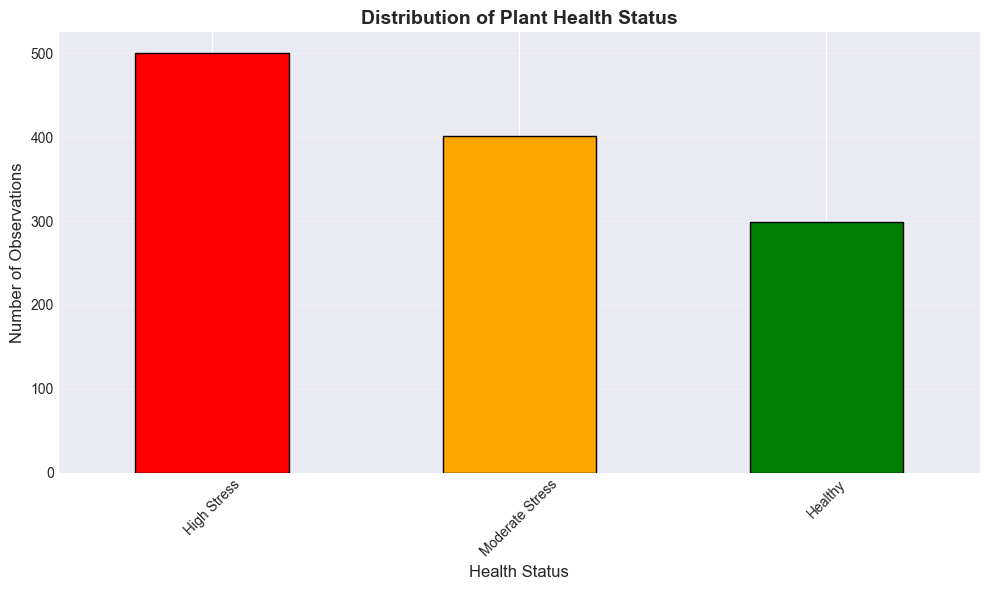


Imbalance ratio: 1.67


In [39]:
# 4. TARGET VARIABLE DISTRIBUTION
print("\n4. TARGET VARIABLE DISTRIBUTION (3-CLASS CLASSIFICATION)")
print("-"*50)
target_dist = df['Plant_Health_Status'].value_counts()
print(target_dist)
print("\nPercentages:")
print(df['Plant_Health_Status'].value_counts(normalize=True) * 100)

# Check classes
classes = df['Plant_Health_Status'].unique()
print(f"\nDetected classes: {sorted(classes)}")
expected_classes = ['Healthy', 'Moderate Stress', 'High Stress']
print(f"Expected classes: {expected_classes}")

# Custom colors per class
colors = {'Healthy': 'green', 'Moderate Stress': 'orange', 'High Stress': 'red'}
class_colors = [colors.get(x, 'steelblue') for x in target_dist.index]

plt.figure(figsize=(10, 6))
target_dist.plot(kind='bar', color=class_colors, edgecolor='black')
plt.title('Distribution of Plant Health Status', fontsize=14, fontweight='bold')
plt.xlabel('Health Status', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Class imbalance check
min_class = target_dist.min()
max_class = target_dist.max()
imbalance_ratio = max_class / min_class
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("⚠ Classes are imbalanced — consider rebalancing techniques.")


5. ANALYSIS OF NUMERICAL VARIABLES
--------------------------------------------------
Numerical variables: 11


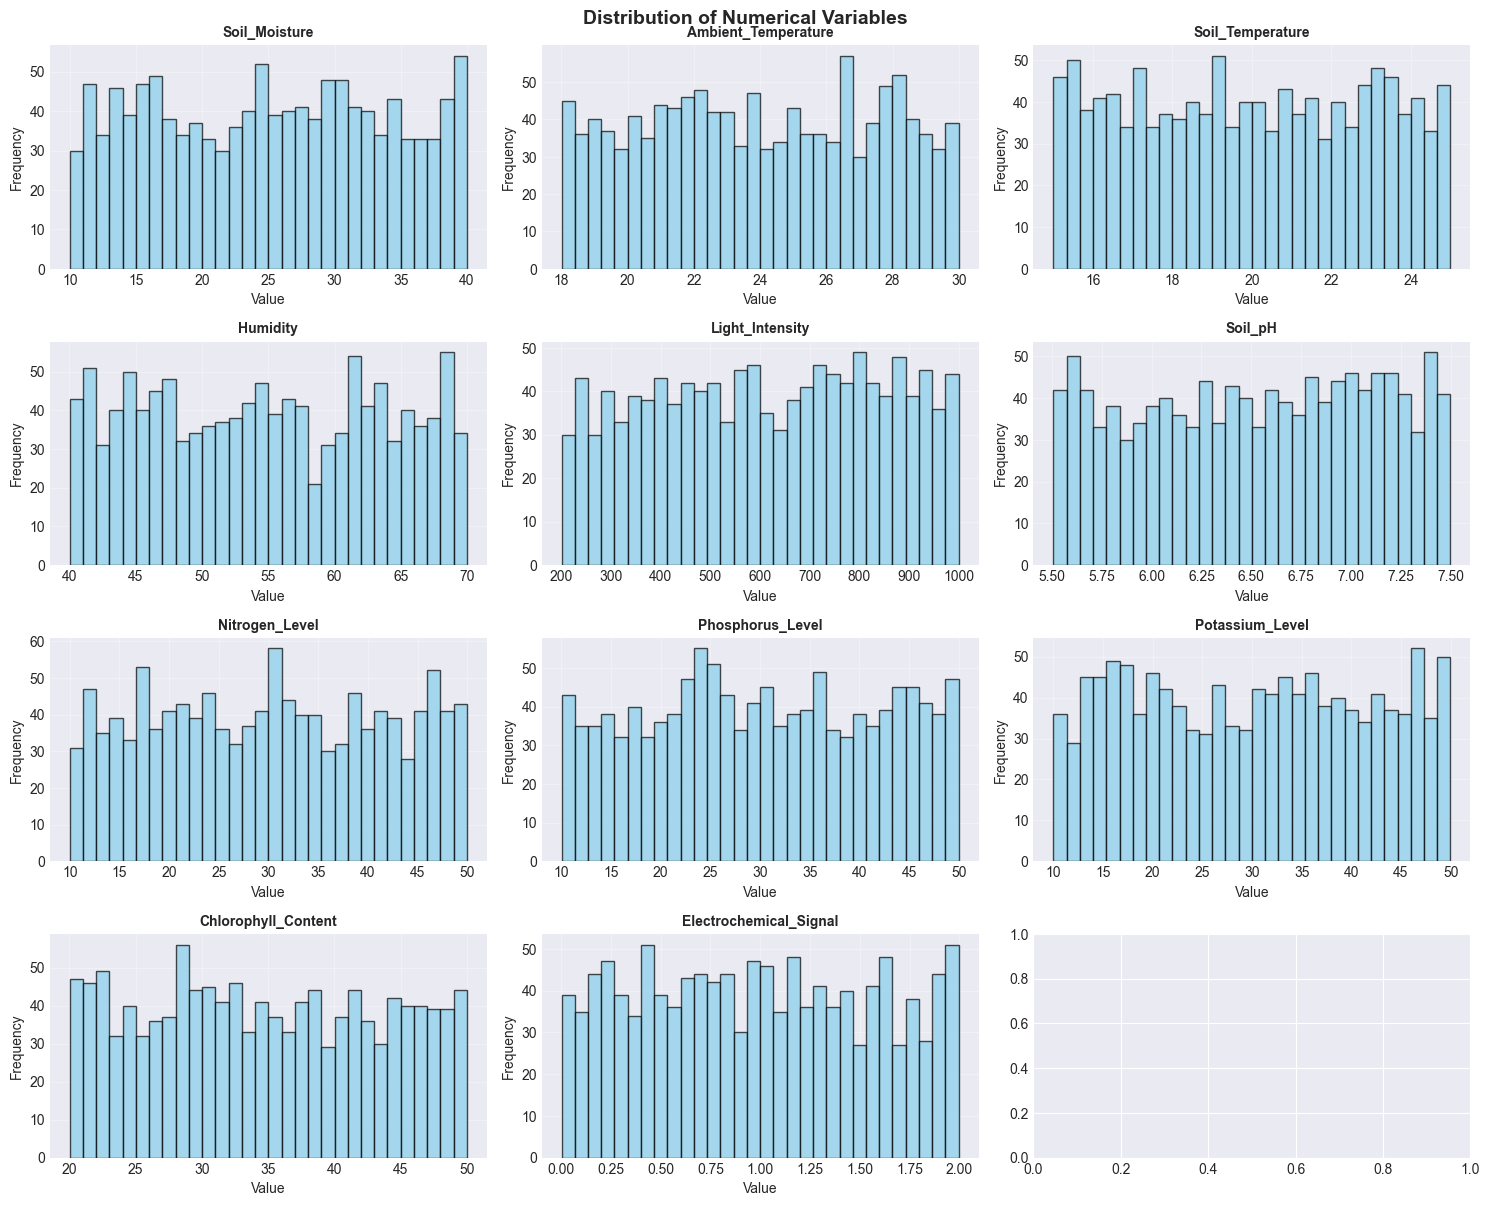

In [40]:
# 5. ANALYSIS OF NUMERICAL VARIABLES
print("\n5. ANALYSIS OF NUMERICAL VARIABLES")
print("-"*50)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Plant_ID') if 'Plant_ID' in numeric_cols else None
print(f"Numerical variables: {len(numeric_cols)}")

# Numerical variable distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.suptitle('Distribution of Numerical Variables', y=1.001, fontsize=14, fontweight='bold')
plt.show()


6. BOXPLOTS BY HEALTH STATUS
--------------------------------------------------


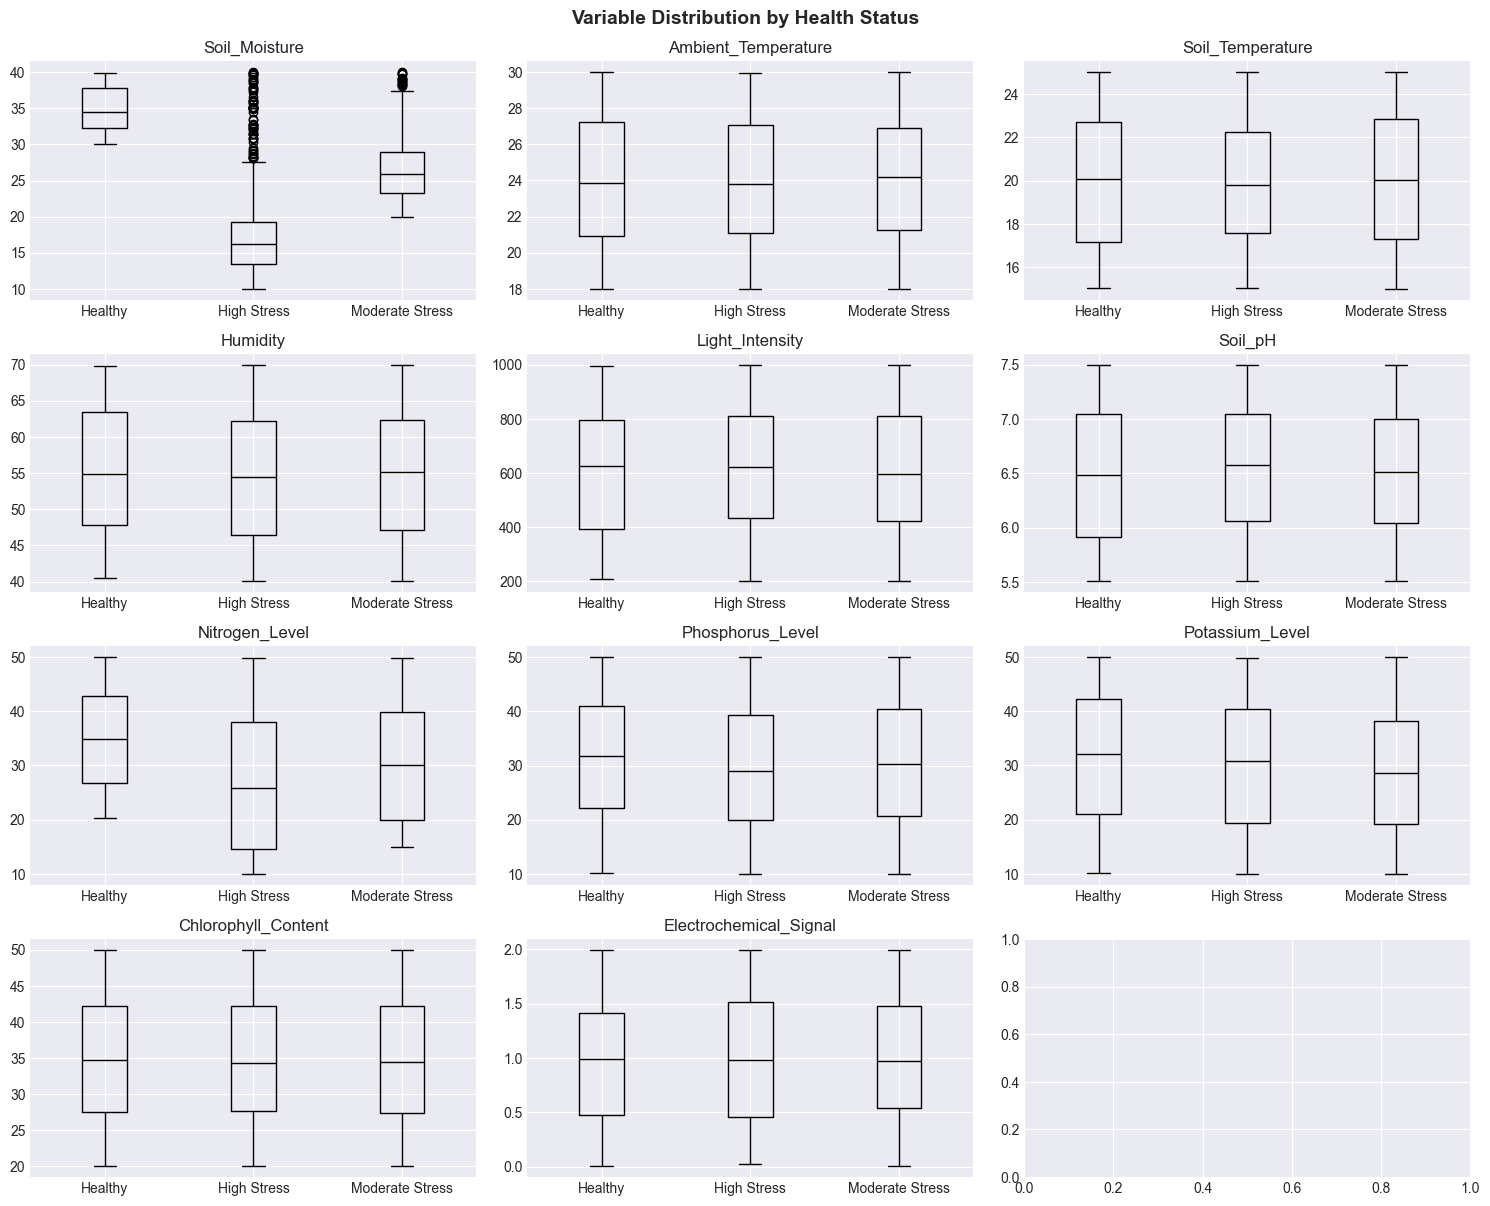

In [41]:
# 6. BOXPLOTS BY HEALTH STATUS
print("\n6. BOXPLOTS BY HEALTH STATUS")
print("-"*50)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_cols):
    df.boxplot(
        column=col,
        by='Plant_Health_Status',
        ax=axes[idx],
        color={"boxes": "black", "whiskers": "black", "medians": "black", "caps": "black"}
    )
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')
    axes[idx].get_figure().suptitle('')
plt.tight_layout()
plt.suptitle(
    'Variable Distribution by Health Status',
    y=1.001,
    fontsize=14,
    fontweight='bold'
)
plt.show()


7. CORRELATION MATRIX
--------------------------------------------------


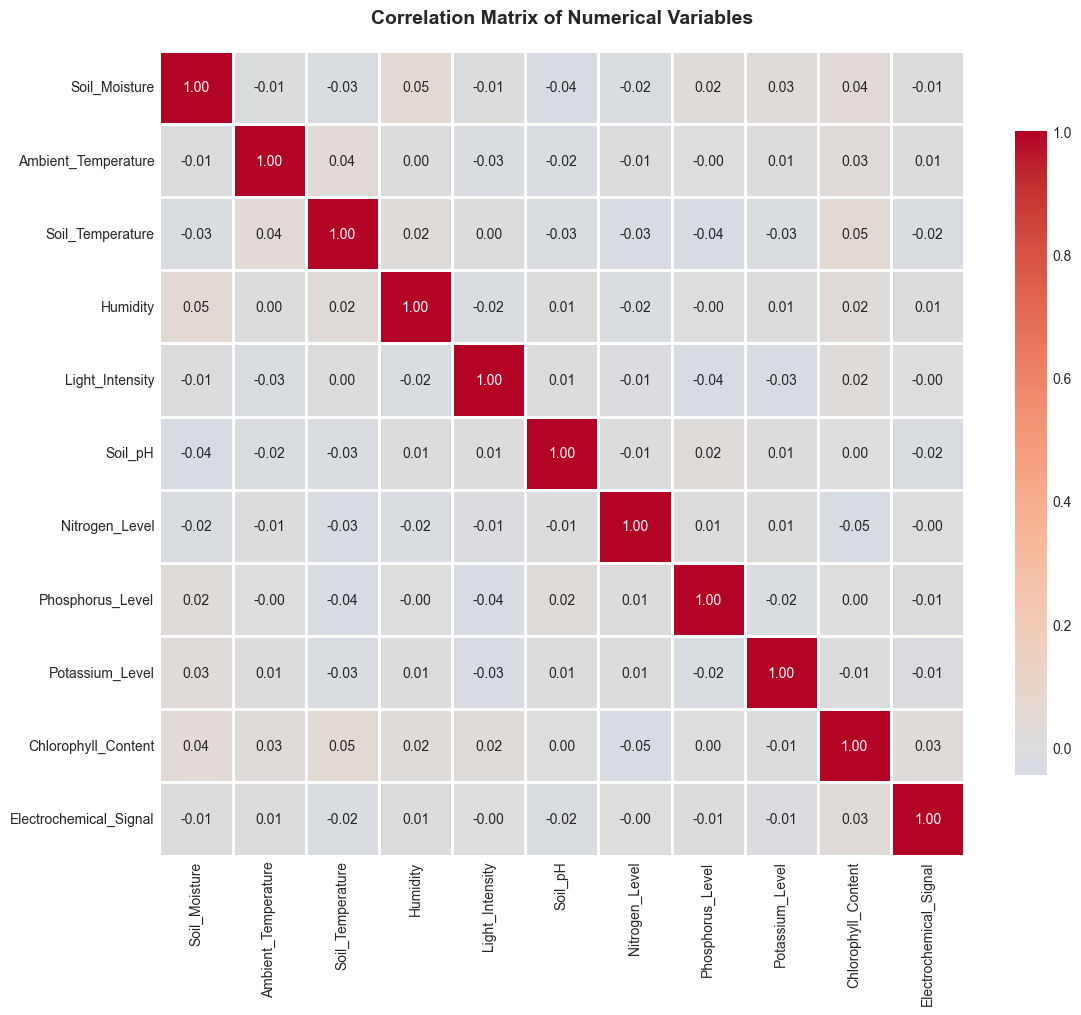


Strongest correlations (|r| > 0.5):


In [42]:
# 7. CORRELATION MATRIX
print("\n7. CORRELATION MATRIX")
print("-"*50)
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Strongest correlations
print("\nStrongest correlations (|r| > 0.5):")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            corr_pairs.append((correlation_matrix.columns[i],
                               correlation_matrix.columns[j],
                               correlation_matrix.iloc[i, j]))
for pair in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")


8. TIME SERIES ANALYSIS
--------------------------------------------------


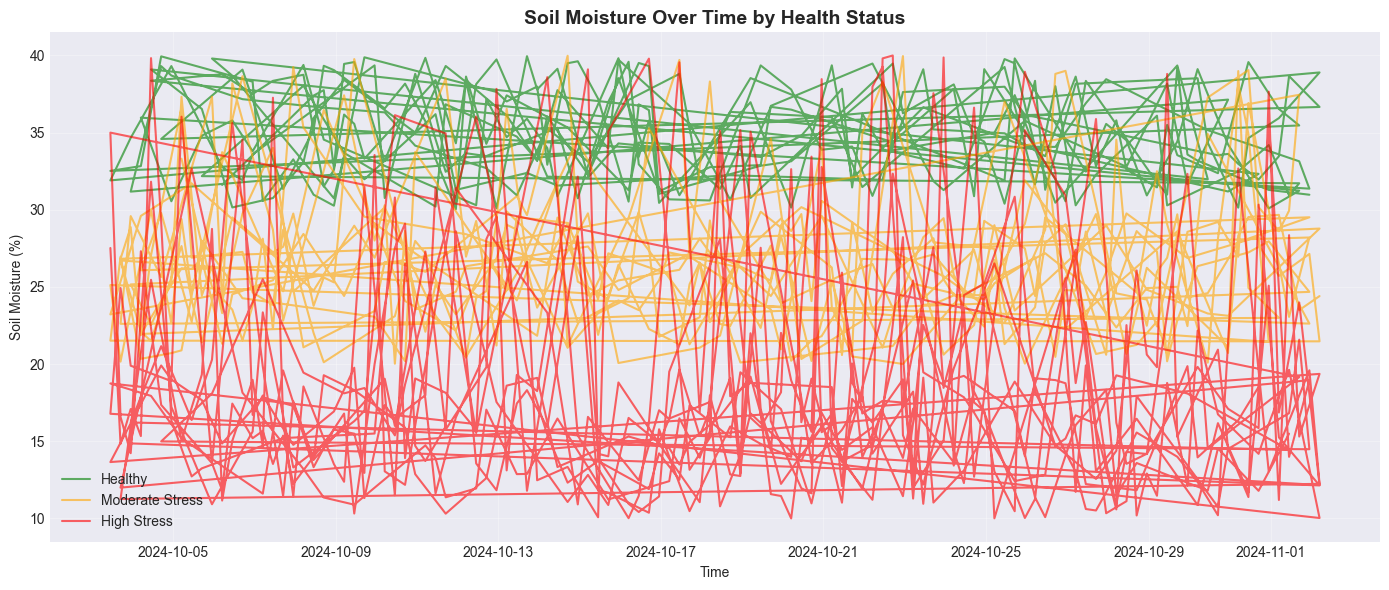

<Figure size 1400x600 with 0 Axes>

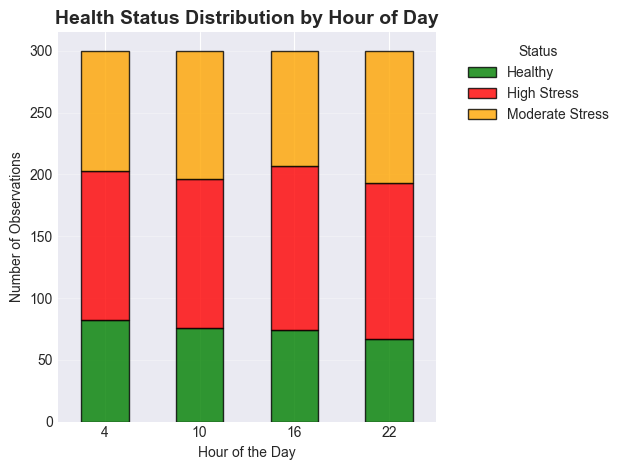

In [43]:
# 8. TIME SERIES ANALYSIS
print("\n8. TIME SERIES ANALYSIS")
print("-"*50)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.date

# Time evolution by health status
colors = {'Healthy': 'green', 'Moderate Stress': 'orange', 'High Stress': 'red'}

plt.figure(figsize=(14, 6))
for status in ['Healthy', 'Moderate Stress', 'High Stress']:
    if status in df['Plant_Health_Status'].unique():
        status_data = df[df['Plant_Health_Status'] == status]
        plt.plot(status_data['Timestamp'], status_data['Soil_Moisture'],
                 label=status, alpha=0.6, color=colors[status])
plt.title('Soil Moisture Over Time by Health Status', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Soil Moisture (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Health status distribution by hour
plt.figure(figsize=(14, 6))
status_by_hour = df.groupby(['Hour', 'Plant_Health_Status']).size().unstack(fill_value=0)
status_by_hour.plot(kind='bar', stacked=True,
                    color=[colors.get(x, 'gray') for x in status_by_hour.columns],
                    edgecolor='black', alpha=0.8)
plt.title('Health Status Distribution by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Observations')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()